<a href="https://colab.research.google.com/github/tarannump096-cpu/My-Projects/blob/main/Probability13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("diet_recommendation_dataset_1000.csv")

In [ ]:
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy
...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic
996,43,1,165,52,19.1,2,175,156,2,Diabetic
997,21,0,159,70,27.7,1,126,177,0,Low Carb
998,36,1,171,41,14.0,2,149,249,0,Diabetic


# **Bivariate Analysis**

In [ ]:
def convert_cat_age(x):
    if x<=30:
        return "young"
    elif x>30 and x<=45:
        return "Adult"
    else:
        return "Senior"

In [ ]:
df["age_cat"]=df["Age"].apply(convert_cat_age)

In [ ]:
df["age_cat"].value_counts()

,count
age_cat,
Senior,414
Adult,323
young,263


In [ ]:
observed_matrix1=pd.crosstab(df["age_cat"],df["Diet"])

In [ ]:
observed_matrix1

Diet,Balanced,Diabetic,Heart Healthy,High Protein,Low Carb
age_cat,,,,,
Adult,14,182,32,25,70
Senior,19,204,40,27,124
young,11,153,20,18,61


In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
chi2,p_value1,dof,expected_matrix=chi2_contingency(observed_matrix1)

In [ ]:
if p_value1>0.05:
    print("both columns are significantly Independent")
else:
    print("both columns are significantly dependent")

both columns are significantly Independent


<Axes: xlabel='Diet', ylabel='Age'>

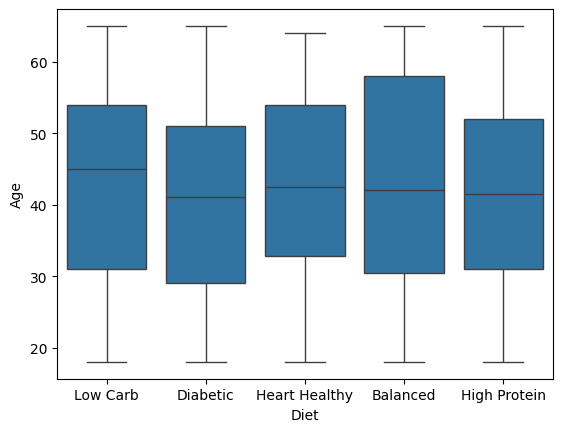

In [ ]:
sns.boxplot(df,x=df["Diet"],y=df["Age"])

In [ ]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'age_cat'],
      dtype='object')

In [ ]:
observed_matrix2=pd.crosstab(df["Gender"],df["Diet"])

In [ ]:
chi2,p_value2,dof,expected_matrix=chi2_contingency(observed_matrix2)

In [ ]:
if p_value2>0.05:
    print("both columns are significantly Independent")
else:
    print("both columns are significantly dependent")

both columns are significantly Independent


In [ ]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'age_cat'],
      dtype='object')

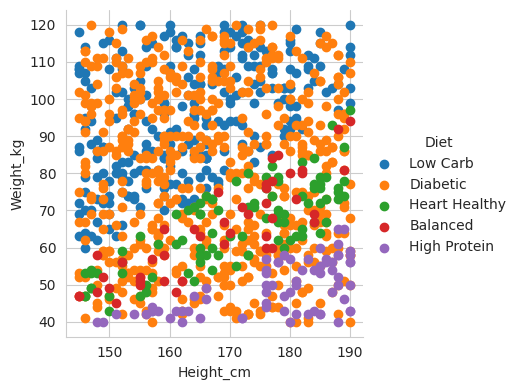

In [ ]:
sns.set_style("whitegrid")
sns.FacetGrid(df,hue="Diet",height=4).map(plt.scatter,"Height_cm","Weight_kg").add_legend();
plt.show()

In [ ]:
from scipy.stats import spearmanr,pearsonr
sp,p_value=spearmanr(df["Height_cm"],df["Weight_kg"])

In [ ]:
sp

np.float64(-0.018549137425943194)

In [ ]:
ps=pearsonr(df["Height_cm"],df["Weight_kg"])

In [ ]:
ps[0]

np.float64(-0.02008359367574801)

In [ ]:
sp>ps[0]

np.True_

In [ ]:
np.sort(df["Height_cm"])

array([145, 145, 145, 145, 145, 145, 145, 145, 145, 145, 145, 145, 145,
       145, 145, 145, 145, 145, 145, 146, 146, 146, 146, 146, 146, 146,
       146, 146, 146, 146, 146, 146, 146, 146, 146, 146, 146, 146, 146,
       146, 146, 146, 146, 146, 146, 146, 146, 146, 147, 147, 147, 147,
       147, 147, 147, 147, 147, 147, 147, 147, 147, 147, 147, 147, 147,
       147, 147, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148,
       148, 148, 148, 148, 148, 148, 148, 148, 148, 149, 149, 149, 149,
       149, 149, 149, 149, 149, 149, 149, 149, 149, 149, 149, 149, 149,
       149, 149, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150,
       150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 151, 151, 151,
       151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151,
       151, 151, 152, 152, 152, 152, 152, 152, 152, 152, 152, 152, 152,
       152, 152, 152, 152, 152, 152, 152, 152, 152, 152, 152, 152, 152,
       152, 152, 152, 152, 152, 152, 152, 152, 153, 153, 153, 15

In [ ]:
def height_cat(x):
    if x<=160:
        return "Small_height"
    elif x>160 and x<=180:
        return "Normal_height"
    else:
        return "High_height"

In [ ]:
df["Height_cat"]=df["Height_cm"].apply(height_cat)

In [ ]:
df["Height_cat"].value_counts()

,count
Height_cat,
Normal_height,440
Small_height,360
High_height,200


In [ ]:
observed_matrix3=pd.crosstab(df["Height_cat"],df["Diet"])

In [ ]:
chi2,p_value3,dof,expected_matrix=chi2_contingency(observed_matrix3)

In [ ]:
if p_value3>0.05:
    print("both columns are significantly Independent")
else:
    print("both columns are significantly dependent")

both columns are significantly dependent


In [ ]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'age_cat', 'Height_cat'],
      dtype='object')

In [ ]:
np.sort(df["Weight_kg"])

array([ 40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  41,  41,  41,
        41,  41,  41,  41,  42,  42,  42,  42,  42,  42,  42,  42,  42,
        42,  42,  42,  42,  42,  42,  43,  43,  43,  43,  43,  43,  43,
        43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  43,  44,  44,
        44,  44,  44,  44,  44,  45,  45,  45,  45,  45,  45,  45,  45,
        46,  46,  46,  46,  46,  46,  46,  47,  47,  47,  47,  47,  47,
        47,  47,  47,  47,  47,  47,  47,  47,  47,  48,  48,  48,  48,
        48,  48,  48,  48,  48,  48,  48,  49,  49,  49,  49,  49,  49,
        49,  49,  49,  50,  50,  50,  50,  50,  50,  50,  50,  50,  50,
        50,  50,  50,  50,  51,  51,  51,  51,  51,  51,  51,  51,  51,
        51,  51,  51,  51,  52,  52,  52,  52,  52,  52,  52,  52,  52,
        52,  52,  52,  52,  52,  53,  53,  53,  53,  53,  53,  53,  53,
        53,  53,  53,  53,  53,  53,  54,  54,  54,  54,  54,  54,  54,
        54,  54,  54,  54,  54,  54,  55,  55,  55,  55,  55,  5

In [ ]:
def weight_cat(x):
    if x<=60:
        return "Under_weight"
    elif x>60 and x<=80:
        return "Normal_weight"
    else:
        return "Over_weight"

In [ ]:
df["Weight_cat"]=df["Weight_kg"].apply(weight_cat)

In [ ]:
df["Weight_cat"].value_counts()

,count
Weight_cat,
Over_weight,475
Under_weight,268
Normal_weight,257


In [ ]:
observed_matrix4=pd.crosstab(df["Weight_cat"],df["Diet"])

In [ ]:
chi2,p_value4,dof,expected_matrix=chi2_contingency(observed_matrix4)

In [ ]:
if p_value4>0.05:
    print("both columns are significantly Independent")
else:
    print("both columns are significantly dependent")

both columns are significantly dependent


In [ ]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'age_cat', 'Height_cat',
       'Weight_cat'],
      dtype='object')

In [ ]:
df["Activity_Level"].unique()

array([0, 1, 2])

In [ ]:
observed_matrix5=pd.crosstab(df["Activity_Level"],df["Diet"])

In [ ]:
chi2,p_value5,dof,expected_matrix=chi2_contingency(observed_matrix5)

In [ ]:
if p_value5>0.05:
    print("both columns are significantly Independent")
else:
    print("both columns are significantly dependent")

both columns are significantly dependent


In [ ]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'age_cat', 'Height_cat',
       'Weight_cat'],
      dtype='object')

In [ ]:
np.sort(df["Sugar_Level"])

array([ 70,  70,  70,  70,  70,  70,  70,  70,  71,  71,  71,  71,  71,
        71,  72,  72,  72,  72,  72,  72,  72,  72,  73,  73,  73,  73,
        73,  73,  73,  73,  73,  73,  74,  74,  74,  74,  74,  74,  74,
        75,  75,  75,  75,  75,  75,  75,  75,  75,  76,  76,  76,  77,
        77,  77,  77,  77,  77,  77,  77,  77,  77,  77,  77,  78,  78,
        78,  78,  78,  78,  78,  79,  79,  79,  79,  79,  79,  79,  79,
        80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  81,  81,  81,
        81,  81,  81,  81,  81,  82,  82,  82,  82,  82,  82,  82,  82,
        82,  82,  82,  82,  82,  82,  82,  82,  82,  83,  83,  83,  83,
        83,  83,  83,  84,  84,  84,  84,  84,  84,  84,  84,  84,  84,
        84,  84,  84,  85,  85,  85,  85,  85,  85,  85,  85,  86,  86,
        86,  86,  86,  86,  86,  86,  86,  86,  86,  86,  86,  87,  87,
        87,  87,  87,  87,  87,  88,  88,  88,  88,  88,  89,  89,  89,
        89,  89,  89,  89,  89,  89,  89,  89,  89,  90,  90,  9

In [ ]:
def sugar_cat(x):
    if x<=80:
        return "Low"
    elif x>80 and x<=140:
        return "Normal"
    else:
        return "High"

In [ ]:
df["Sugar_cat"]=df["Sugar_Level"].apply(sugar_cat)

In [ ]:
df["Sugar_cat"].value_counts()

,count
Sugar_cat,
Normal,544
High,368
Low,88


In [ ]:
observed_matrix6=pd.crosstab(df["Sugar_cat"],df["Diet"])

In [ ]:
chi2,p_value6,dof,expected_matrix=chi2_contingency(observed_matrix6)

In [ ]:
if p_value6>0.05:
    print("both columns are significantly Independent")
else:
    print("both columns are significantly dependent")

both columns are significantly dependent


In [ ]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'age_cat', 'Height_cat',
       'Weight_cat', 'Sugar_cat'],
      dtype='object')

In [ ]:
def cholestrol_cat(x):
    if x<=200:
        return "Desirable"
    elif x>200 and x<=240:
        return "Borderline High"
    else:
        return "High"

In [ ]:
df["cholestrol_cat"]=df["Cholesterol"].apply(cholestrol_cat)

In [ ]:
df["cholestrol_cat"].value_counts()

,count
cholestrol_cat,
Desirable,410
Borderline High,304
High,286


In [ ]:
observed_matrix7=pd.crosstab(df["cholestrol_cat"],df["Diet"])

In [ ]:
chi2,p_value7,dof,expected_matrix=chi2_contingency(observed_matrix7)

In [ ]:
if p_value7>0.05:
    print("both columns are significantly Independent")
else:
    print("both columns are significantly dependent")

both columns are significantly dependent


In [ ]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'age_cat', 'Height_cat',
       'Weight_cat', 'Sugar_cat', 'cholestrol_cat'],
      dtype='object')

In [ ]:
df["Goal"].unique()

array([2, 0, 1])

In [ ]:
def BMI_cat(x):
  if x<18.5:
    return "Underweight"
  elif x>=18.5 and x<25:
    return "Normal"
  elif X>=25 and X<30:
    return "Obese"

In [ ]:
def BMI_cat(x):
  if x<18.5:
    return "Underweight"
  elif x>=18.5 and x<25:
    return "Normal"
  elif x>=25 and x<30:
    return "Obese"
  else:
    return "Extremely Obese" # Added a return for cases >= 30, as the original function was incomplete.
df["BMI_cat"]=df["BMI"].apply(BMI_cat)

In [ ]:
df["BMI_cat"].value_counts()

,count
BMI_cat,
Extremely Obese,445
Normal,242
Obese,164
Underweight,149


In [ ]:
observed_matrix8=pd.crosstab(df["BMI_cat"],df["Diet"])

In [ ]:
chi2,p_value8,dof,expected_matrix=chi2_contingency(observed_matrix8)

In [ ]:
if p_value7>0.05:
    print("both columns are significantly Independent")
else:
    print("both columns are significantly dependent")

both columns are significantly dependent


In [ ]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'age_cat', 'Height_cat',
       'Weight_cat', 'Sugar_cat', 'cholestrol_cat', 'BMI_cat'],
      dtype='object')